#**Project 2**

Iris Wu

Data 201 Spring 2026

##**Introduction**

As a Goodreads user, I find the site helpful to track books I have read, discover new books, and read book reviews from a diverse user base. I have also always been curious about how Goodreads ratings are calculated. For this project, I decided to examine book ratings by  using the Goodreads Best Books Ever dataset. This dataset compiles information about 52,478 books that are on the Goodreads Best Books Ever list, including overall rating, number of ratings, genres, awards, and pages. The Goodreads Best Books Ever list contains 77,945 books and has collected votes from 290,733 voters. Although it was created in 2008, it is continuously updated. However, the dataset used in this project was created in 2020, so it does not contain the most updated information. Even so, the dataset provides insights on how Goodreads books are rated.

For this project, I chose to only focus on the top 500 most popular books on the list, as sorted by number of ratings. Books with fewer ratings are more likely to have extreme scores, and I wanted to reduce the effect of misleading data points on my linear regression model.

Data Citation: Lorena Casanova Lozano, & Sergio Costa Planells. (2020). Best Books Ever Dataset (1.0.0) [Data set]. Zenodo.

##**Data Overview**

In [34]:
#Load the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [35]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')


df_books = pd.read_csv("/content/drive/MyDrive/books_1.Best_Books_Ever.csv", encoding= "latin1")
df_books.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1


###**Dataset Structure**

In [36]:
#Size of dataset
rows, columns = df_books.shape
print(f"The dataset has {rows} rows and {columns} columns")

The dataset has 52478 rows and 25 columns


There are 52,478 rows and 25 columns in this dataset. Each row represents one book from the Goodreads Best Books Ever list.

###**Table of Variables**

For this project, the following variables were examined:

|Name    |  Definition | Type  |
|---|---|---|
|title   | Title of book  | Categorical  |
|author   | Author of book  |  Categorical |
| rating  | Goodreads rating of book out of 5 stars  | Quantitative  |
| pages  | Number of pages in book  |  Quantitative |
| awards  | Literary awards that the book won: converted into a binary column where has_award is 1 and no_award is 0  |   Categorical|
| numRatings  | Total number of ratings   | Quantitative  |
| ratingsByStars |  Number of ratings by star: filtered for number of 5-star ratings | Quantitative  |
| bbeVotes | Number of votes received for the Best Books Ever list | Quantitative  |
| | |




###**Data Cleaning & Transformations**


In [37]:
#Delete variables that will not be used in this project
df_books1 = df_books.drop(["bookId",
                       "series",
                       "description",
                       "language",
                       "isbn",
                       "genres",
                       "characters",
                       "bookFormat",
                       "edition",
                       "publisher",
                       "publishDate",
                       "firstPublishDate",
                       "likedPercent",
                       "setting",
                       "coverImg",
                       "bbeScore",
                       "price"], axis = 1)
df_books1.head()


,title,author,rating,pages,awards,numRatings,ratingsByStars,bbeVotes
0,The Hunger Games,Suzanne Collins,4.33,374,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",30516
1,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.50,870,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",26923
2,To Kill a Mockingbird,Harper Lee,4.28,324,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",23328
3,Pride and Prejudice,"Jane Austen, Anna Quindlen (Introduction)",4.26,279,[],2998241,"['1617567', '816659', '373311', '113934', '767...",20452
4,Twilight,Stephenie Meyer,3.60,501,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",14874


In [38]:
#Filter for top 500 books based on popularity (number of ratings)
df_top500 = df_books1.sort_values(by = "numRatings", ascending = False).head(500)
df_top500.head()

,title,author,rating,pages,awards,numRatings,ratingsByStars,bbeVotes
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,"[""Mythopoeic Fantasy Award for Children's Lite...",7048471,"['4578137', '1611874', '600384', '139551', '11...",7348
0,The Hunger Games,Suzanne Collins,4.33,374,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",30516
4,Twilight,Stephenie Meyer,3.60,501,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",14874
2,To Kill a Mockingbird,Harper Lee,4.28,324,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",23328
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,['Grammy Award Nominee for Best Spoken Word Al...,3775504,"['1345866', '1266424', '798955', '252115', '11...",8142


For the ratingsByStars variable, I only looked at the number of 5-star ratings to examine its correlation with a book's overall Goodreads rating.



In [39]:
import ast
df_top500['ratings_5star'] = df_top500['ratingsByStars'].apply(lambda x: int(ast.literal_eval(x)[0]))
df_top500.head()

,title,author,rating,pages,awards,numRatings,ratingsByStars,bbeVotes,ratings_5star
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,"[""Mythopoeic Fantasy Award for Children's Lite...",7048471,"['4578137', '1611874', '600384', '139551', '11...",7348,4578137
0,The Hunger Games,Suzanne Collins,4.33,374,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",30516,3444695
4,Twilight,Stephenie Meyer,3.60,501,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",14874,1751460
2,To Kill a Mockingbird,Harper Lee,4.28,324,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",23328,2363896
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,['Grammy Award Nominee for Best Spoken Word Al...,3775504,"['1345866', '1266424', '798955', '252115', '11...",8142,1345866


In [40]:
#Since there is a new ratings_5star column, delete the ratingsByStars column
df_top500 = df_top500.drop(["ratingsByStars"], axis = 1)
df_top500.head()

,title,author,rating,pages,awards,numRatings,bbeVotes,ratings_5star
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,"[""Mythopoeic Fantasy Award for Children's Lite...",7048471,7348,4578137
0,The Hunger Games,Suzanne Collins,4.33,374,['Locus Award Nominee for Best Young Adult Boo...,6376780,30516,3444695
4,Twilight,Stephenie Meyer,3.60,501,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,14874,1751460
2,To Kill a Mockingbird,Harper Lee,4.28,324,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,23328,2363896
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,['Grammy Award Nominee for Best Spoken Word Al...,3775504,8142,1345866


Using the awards variable, I created a binary column to classify books into has_award (1) and no_award (0). I wanted to compare whether books with awards were more highly rated than books with none.

In [41]:
df_top500['has_award'] = df_top500['awards'].apply(lambda x: 0 if pd.isna(x) or x == '[]' else 1)
df_top500.head()


,title,author,rating,pages,awards,numRatings,bbeVotes,ratings_5star,has_award
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,"[""Mythopoeic Fantasy Award for Children's Lite...",7048471,7348,4578137,1
0,The Hunger Games,Suzanne Collins,4.33,374,['Locus Award Nominee for Best Young Adult Boo...,6376780,30516,3444695,1
4,Twilight,Stephenie Meyer,3.60,501,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,14874,1751460,1
2,To Kill a Mockingbird,Harper Lee,4.28,324,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,23328,2363896,1
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,['Grammy Award Nominee for Best Spoken Word Al...,3775504,8142,1345866,1


In [42]:
#Delete awards column
df_top500 = df_top500.drop(["awards"], axis = 1)
df_top500.head()

,title,author,rating,pages,numRatings,bbeVotes,ratings_5star,has_award
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,7048471,7348,4578137,1
0,The Hunger Games,Suzanne Collins,4.33,374,6376780,30516,3444695,1
4,Twilight,Stephenie Meyer,3.60,501,4964519,14874,1751460,1
2,To Kill a Mockingbird,Harper Lee,4.28,324,4501075,23328,2363896,1
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,3775504,8142,1345866,1


##**Data Analysis and Modeling**

###**a. Data Exploration and Visualization**

####**Plot 1: Number of Ratings vs. Rating**

What is the relationship between a book's popularity on Goodreads (by number of ratings) and its overall rating out of 5 stars? Do more popular books have higher ratings?

In [43]:
#First apply log transformation to numRatings
df_top500['log_numRatings'] = np.log(df_top500['numRatings'])
df_top500.head()


,title,author,rating,pages,numRatings,bbeVotes,ratings_5star,has_award,log_numRatings
32,Harry Potter and the Sorcerer's Stone,"J.K. Rowling, Mary GrandPrÃ© (Illustrator)",4.47,309,7048471,7348,4578137,1,15.768321
0,The Hunger Games,Suzanne Collins,4.33,374,6376780,30516,3444695,1,15.668174
4,Twilight,Stephenie Meyer,3.60,501,4964519,14874,1751460,1,15.417827
2,To Kill a Mockingbird,Harper Lee,4.28,324,4501075,23328,2363896,1,15.319827
27,The Great Gatsby,"F. Scott Fitzgerald, Francis Scott Fitzgerald",3.92,200,3775504,8142,1345866,1,15.144044


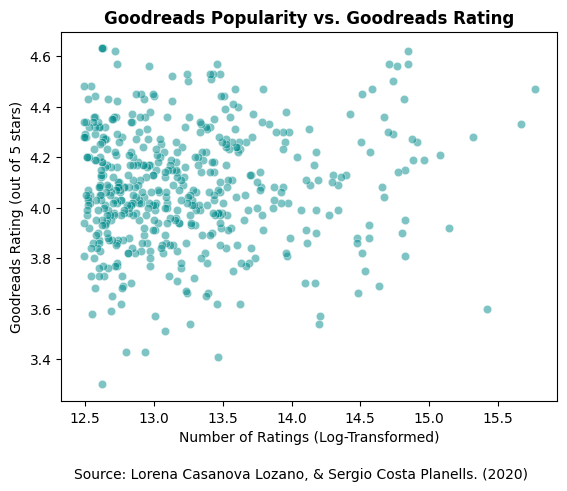

In [44]:
sns.scatterplot(data = df_top500, x = "log_numRatings", y = "rating", alpha = 0.5, color = "darkcyan")
plt.title("Goodreads Popularity vs. Goodreads Rating", fontweight = "bold")
plt.xlabel("Number of Ratings (Log-Transformed)")
plt.ylabel("Goodreads Rating (out of 5 stars)")
plt.figtext(0.5, -0.05, "Source: Lorena Casanova Lozano, & Sergio Costa Planells. (2020)", ha="center")
plt.show()

More popular books do not correlate with a higher rating. The popularity of a book only indicates that many people have read it. However, whether all readers like the book and rate it highly is not a given. A popular book can be divisive, with many ratings on each extreme, leading to an average number of stars, or it can be widely-beloved, with a high number of stars.

####**Plot 2: Awards vs. Rating**

Are books that won or were nominated for awards more highly rated than those without?

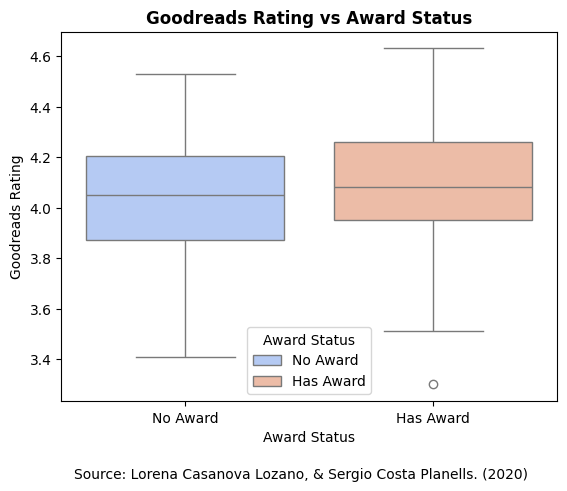

In [45]:
sns.boxplot(data = df_top500, x = "has_award", y = "rating", hue = "has_award", palette = "coolwarm")
plt.title("Goodreads Rating vs Award Status", fontweight = "bold")
plt.xlabel("Award Status")
plt.ylabel("Goodreads Rating")
plt.figtext(0.5, -0.05, "Source: Lorena Casanova Lozano, & Sergio Costa Planells. (2020)", ha="center")
plt.xticks([0, 1], ['No Award', 'Has Award'])
plt.legend(labels=['No Award', 'Has Award'], title='Award Status')
plt.show()


Books that won or were nominated for awards have a slightly higher median rating, but there is not a significant difference. A book that has an award might attract more readers. However, individual enjoyment of a book is not necessarily influenced by the awards it receives.





####**Plot 3: Distribution of Rating**

What does the distribution of Goodreads ratings for the top 500 books on the Best Books Ever list look like? Are ratings clustered around a certain value?




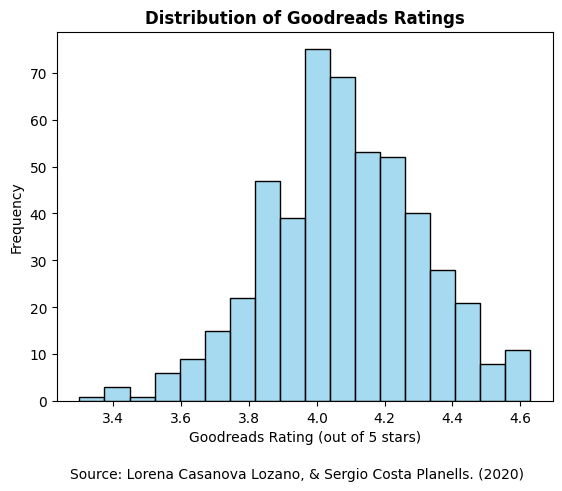

In [46]:
sns.histplot(data = df_top500, x = "rating", kde = False, color = "skyblue")
plt.title("Distribution of Goodreads Ratings", fontweight = "bold")
plt.xlabel("Goodreads Rating (out of 5 stars)")
plt.ylabel("Frequency")
plt.figtext(0.5, -0.05, "Source: Lorena Casanova Lozano, & Sergio Costa Planells. (2020)", ha="center")
plt.show()


The distribution is slightly left-skewed, and most ratings cluster between 4 to 4.2 stars. This suggests that most Goodreads users tend to rate books on the higher end. Users liklely gravitate towards books they believe they will enjoy, which in turn leads to higher ratings.

###**b. Train/Test Split**




I chose a standard 80/20 split because with 500 rows, 400 training observations and 100 test observations is enough data to produce a reliable model. If the dataset were smaller, I would choose a 70/30 split to presever more test data.

In [47]:
#Convert pages variable to numeric
df_top500['pages'] = pd.to_numeric(df_top500['pages'], errors='coerce')


In [48]:
#Train/Test Split
features = ["numRatings", "pages", "bbeVotes", "ratings_5star", "has_award"]
target = "rating"

df_model1 = df_top500[features + [target]].dropna()

X = df_model1[features]
y = df_model1[target]

#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)



###**c. Baseline Model**

For my baseline model, I chose to examine whether the following variables were reliable predictors of a book's rating.  
          

*   numRating
    - Although the scatterplot above shows no correlation between a book's popularity and its overall rating, I wanted to test the relationship in a more rigorous model.  
*   pages
    - I was curious whether the length of a book could influence the rating — perhaps readers prefer shorter books over longer ones, or vice versa.                 
*   bbeVotes
    - Assumption: Books with more votes to be on the "Best Books Ever" list likely have higher ratings.
*   ratings_5star
     - Assumption: Books with a higher number of five-star rating likely have higher ratings overall.
*   has_award
    - Assumption: Books that won or were nominated for awards likely have higher ratings overall.






In [49]:
#Model 1 Summary
X_train_sm = sm.add_constant(X_train)
model1_sm = sm.OLS(y_train, X_train_sm).fit()
print(model1_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     81.62
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.16e-58
Time:                        03:46:37   Log-Likelihood:                 171.74
No. Observations:                 400   AIC:                            -331.5
Df Residuals:                     394   BIC:                            -307.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.0581      0.022    184.625

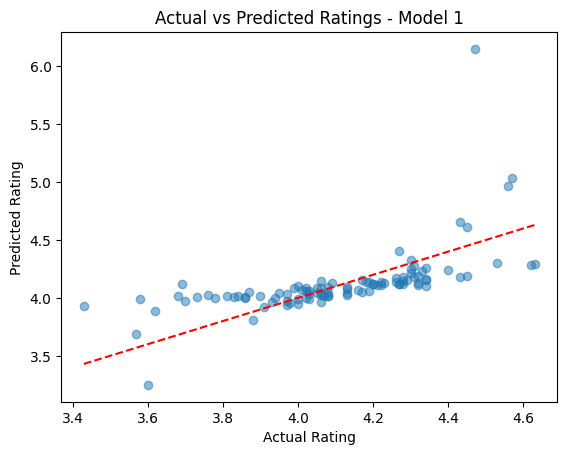

In [50]:
plt.scatter(y_test, y_pred1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings - Model 1")
plt.show()


The variables with p-values greater than 0.05 are `bbeVotes` and `has_award`, so they are not statistically significant. `bbeVotes` is likely redundant with `numRatings` — popular books have both a high number of ratings and a high number of votes to be on the Best list. The insignificance of `has_award` to the model confirms the boxplot above. Awards reflect critical success but not necessarily the average reader's rating of a book.

The condition number is large, indicating multicollinearity. This multicollinearity is likely between `ratings_5star` and `numRatings`, as books with a high number of ratings also have a high number of five-star ratings.

###**d. Improving the Model**

To improve the model, I removed the variables that are not statistically significant, `bbeVotes` and `has_award`. I also removed ratings_5star since it was likely contributing to multicollinearity.

In [51]:
features2 = ["numRatings", "pages"]
target = "rating"

df_model2 = df_top500[features2 + [target]].dropna()

X2 = df_model2[features2]
y2 = df_model2[target]

#Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)


#Fit
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)


In [52]:
#Model 2 Summary
X_train2_sm = sm.add_constant(X_train2)
model2_sm = sm.OLS(y_train2, X_train2_sm).fit()
print(model2_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     13.27
Date:                Fri, 01 May 2026   Prob (F-statistic):           2.65e-06
Time:                        03:46:37   Log-Likelihood:                 42.497
No. Observations:                 400   AIC:                            -78.99
Df Residuals:                     397   BIC:                            -67.02
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9554      0.026    154.843      0.0

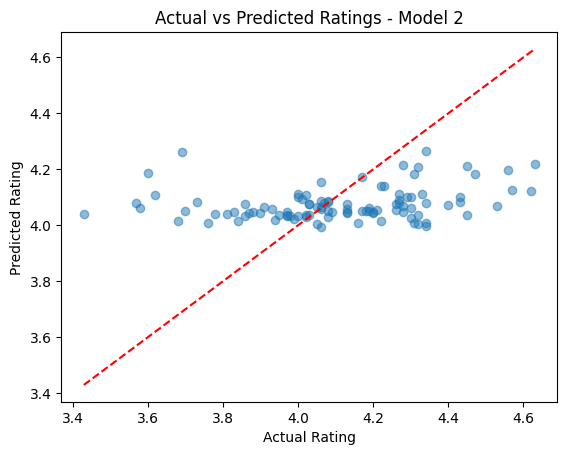

In [53]:
plt.scatter(y_test2, y_pred2, alpha=0.5)
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings - Model 2")
plt.show()

Despite removing two statistically insignificant variables, Model 2 is weaker than the initial model. As evidenced in the plot, the data points are spread out instead of clustered along the line. The weakness of this model is likely due to the removal of `ratings_5star`. Since the number of five-star ratings directly contributes to the overall rating calculation, it is a proxy for the target variable and therefore has strong explanatory power.

####**Final Model**

For the final model, I added back `ratings_5`.

In [54]:
features3 = ["numRatings", "pages", "ratings_5star"]
target = "rating"

df_model3 = df_top500[features3 + [target]].dropna()

X3 = df_model3[features3]
y3 = df_model3[target]

#Split
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

#Fit
model3 = LinearRegression()
model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)


In [55]:
#Model 3 Summary
X_train3_sm = sm.add_constant(X_train3)
model3_sm = sm.OLS(y_train3, X_train3_sm).fit()
print(model3_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     135.2
Date:                Fri, 01 May 2026   Prob (F-statistic):           2.61e-60
Time:                        03:46:38   Log-Likelihood:                 170.60
No. Observations:                 400   AIC:                            -333.2
Df Residuals:                     396   BIC:                            -317.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.0703      0.020    208.281

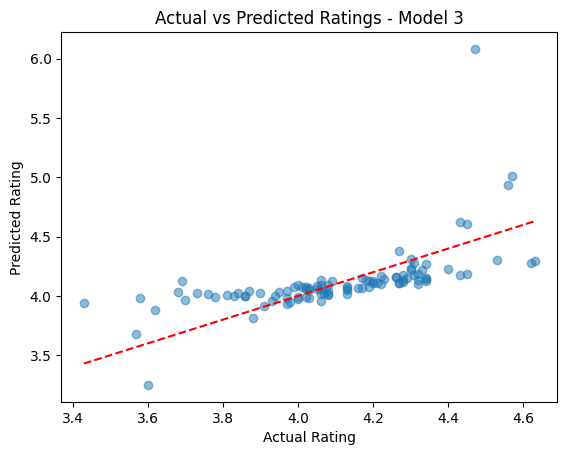

In [56]:
plt.scatter(y_test3, y_pred3, alpha=0.5)
plt.plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings - Model 3")
plt.show()


The final model is similar to the first model, but statistically insignificant variables have been removed.

###**e. Comparing Models**

In [57]:
#Comparing R-squared
print(model1.score(X_test, y_test))
print(model2.score(X_test2, y_test2))
print(model3.score(X_test3, y_test3))



0.03935048734989477
0.05250846582164481
0.08460406227022266


The gap between the trained R-squared and the test R-squared for Model 1 indicates that it is overfitting the data. Although it fits the training data well, it does not generalize to new, unseen book data. Model 3 also overfits the data, but to a less severe degree than Model 1, so it is more reliable. Model 2 does not have an overfitting problem, but it is a consistently weak model for both training and testing data.

In [58]:
#Compare RMSEs

#Model 1
y_pred1 = model1.predict(X_test)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
print("Model 1 RMSE:", rmse1)

#Model 2
y_pred2 = model2.predict(X_test2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
print("Model 2 RMSE:", rmse2)


# Model 3
y_pred3 = model3.predict(X_test3)
rmse3 = np.sqrt(mean_squared_error(y_test3, y_pred3))
print("Model 3 RMSE:", rmse3)


Model 1 RMSE: 0.23964485147128653
Model 2 RMSE: 0.23799798974007993
Model 3 RMSE: 0.2339322565250776


Although the RMSEs of each model are similar, Model 3 has the lowest RMSE and therefore the lowest prediction error. Since ratings range from 3.4 to 4.6 stars, Model 3's average prediction error is around 0.234 stars. If a book's actual rating is 4 stars, then Model 3's prediction will fall between 3.77 to 4.23 stars.

###**f. Interpretation of Final Model**

The final model is:

**Predicted Goodreads Rating ~  0.00000154(ratings_5star) + 0.0000962(pages) - 0.000000717(numRatings)**

* For every one-unit increase in the number of five-star ratings a book has, the predicted overall rating of a book increases by 0.00000154.

* For every one-unit increase in the number of pages a book has, the predicted overall rating increases by 0.0000962.

* For every one-unit increase in the number of ratings a book has,the predicted overall rating decreases by 0.000000717. This seems surprising at first, but since popular books reach a broader audience, they are likely to attract more varied ratings that can pull the average down.

Overall, although these variables are statistically significant, they have a negligible effect on the overall rating of a book because their coefficeints are so small. As this model suggests, quantitative variables are not the strongest predictors of overall rating.

###**g. Predictions**

I asked the model to predict ratings for three books taken from my own Goodreads "Want to Read" list.

In [59]:
new_books = pd.DataFrame({
    'numRatings': [94563, 30571, 2037],
    'pages': [231, 183, 320],
    'ratings_5star': [26879, 14014, 615]
})

predictions = model3.predict(new_books)
print(predictions)


[4.06600244 4.08751213 4.10056083]


I took the actual ratings of the three books from my list and compared them to the model's predictions:

| Book    | Predicted Rating | Actual Rating |
|---------|------------------|---------------|
| Book 1  | 4.07 stars       | 3.90 stars    |
| Book 2  | 4.09 stars       | 4.26 stars    |
| Book 3  | 4.10 stars       | 4.0 stars     |



For these three books, the model's predictions were off by 0.1 to 0.17 stars. Although the errors are relatively small, three data points are not enough to generalize the entire model's performance. Nonetheless, based on the previously calculated R-squared and RMSE, this model is the strongest of the three models that were tested.

##**Conclusion and Recommendations**

Despite improvements, the general weakness of the models suggest that quantitative variables are not the best predictors of a book's overall rating. Instead, categorical variables such as author reputation, genre popularity, and writing style are more likely to determine a book's rating. Future models should factor in more categorical variables.

Nonetheless, there may be quantitative variables that are stronger predictors than the ones chosen here. The age of a book, found by subtracting the current year from its initial publication year, could influence the overall rating. For example, classics are named so because they have existed for decades or centuries and remain widely- read and loved today. The age variable should be added to a future model.

Finally, the size of the data may have also limited model performance. I chose the top 500 books for reliability purposes, but in the future, I would start with a larger sample size, with a minimum of 1,000 observations.



